In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

TRAIN_PATH = "Dataset/train"
TEST_PATH = "Dataset/test"
MODEL_PATH = "Model/model.xml"

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

In [3]:
def preprocess(img):
    img = cv2.resize(img, (100,100))
    img = cv2.equalizeHist(img)
    return img

def detect_face(img):
    faces = face_cascade.detectMultiScale(img, 1.02, 2, minSize=(30,30))
    if len(faces) > 0:
        x,y,w,h = faces[0]
        return preprocess(img[y:y+h, x:x+w]), (x,y,w,h)
    
    w,h = img.shape
    return preprocess(img), (0,0,w,h)

In [ ]:
def load_data(folder_path, class_names):
    faces, labels = [], []
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder_path, class_name)
        if not os.path.dirname(class_path):
            continue

        for filename in sorted(os.listdir(class_path)):
            img = cv2.imread(os.path.join(class_path, filename), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            face_img,_ = detect_face(img)
            faces.append(face_img)
            labels.append(label)

    return faces, np.array(labels, dtype=np.int32)

In [6]:
def train_test():
    class_names = sorted(os.listdir(TRAIN_PATH))

    print("Training Data Loading...")
    train_faces, train_labels = load_data(TRAIN_PATH, class_names)
    if train_faces is None:
        print("Training Data Not Found!")
    
    face_recognizer = cv2.face.LBPHFaceRecognizer_create()
    face_recognizer.train(train_faces, train_labels)

    print("Test Data Loading...")
    test_faces, test_labels = load_data(TEST_PATH, class_names)
    if test_faces is None:
        print("Testing Data Not Found!")

    correct = 0
    for face, true_labels in zip(test_faces, test_labels):
        predicted_label, confidence = face_recognizer.predict(face)
        status = "RIGHT" if predicted_label == true_labels else "WRONG"
        correct += predicted_label == true_labels
        print(f"Actual : {true_labels} | Predict : {predicted_label} | Confidence : {confidence:.2f} | {status}")

    print(f"Average Accuracy: {correct/len(test_faces) * 100:.2f}%")

    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    face_recognizer.write(MODEL_PATH)
    print("Model Saved Successfully!")

In [17]:
def predict(img_path):
    if not os.path.exists(MODEL_PATH):
        print("Model Not Found! Please Train Model First!")
        return

    class_names = sorted(os.listdir(TRAIN_PATH))
    face_recognizer = cv2.face.LBPHFaceRecognizer_create()
    face_recognizer.read(MODEL_PATH)

    img = cv2.imread(img_path)
    if img is None:
        print("Error! Cant Read Image")
        return

    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face_img, (x,y,w,h) = detect_face(img_gray)
    predict_label, confidence = face_recognizer.predict(face_img)
    predict_class = class_names[predict_label]

    cv2.rectangle(img, (x, y), (x+w, y+h), (255,0,0), 2)
    cv2.putText(img, f"{predict_class} | {confidence:.2f}", (x, y-10), cv2.FONT_HERSHEY_PLAIN, 1, (0,255,0))

    print(f"{img_path} detected as {predict_label}")
    print(f"Detected Subject    : {predict_class}")
    print(f"Confidence          : {confidence:.2f}")
    print(f"Detected Face Loc   : x={x}, y={y}, w={w}, h={h}")

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    



===FACE DETECTION===
1. Train and Test Model
2. Predict
3. Exit
/Users/fadh/Documents/BINUS/Semester 4/LAB AI Semester 4/LAB Computer Vision/LatihanQuizpt2/Dataset/test/s40/10.pgm detected as 34
Detected Subject    : s40
Confidence          : 55.49
Detected Face Loc   : x=2, y=32, w=68, h=68


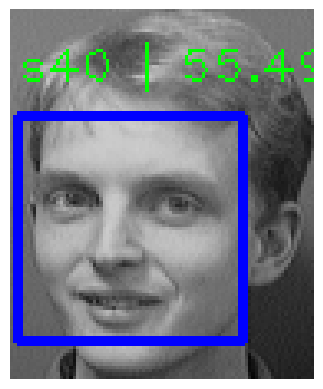

===FACE DETECTION===
1. Train and Test Model
2. Predict
3. Exit
Exit...


In [19]:
def main():
    while True:
        print("===FACE DETECTION===")
        print("1. Train and Test Model")
        print("2. Predict")
        print("3. Exit")
        choice = input("Input Your Choice (1-3): ")
        if choice == '1':
            train_test()
        elif choice == '2':
            img_path = input("Enter the path to the image for testing (absolute path): ")
            predict(img_path)
        elif choice == '3':
            print("Exit...")
            break
        else:
            print("Invalid Input. Please Choice 1-3!")

main()